# Outlines
* Required Installation
* QR-PUF
* BB84 Qbit
* Implementation
    * A-PUF Implementation
    * Qiskit Encoding & Circuit Measurement
    * ML-Attack (Logistic Regression)

## Required Installation

Run the cell below once to install the required packages. (Drop `--break-system-packages` if you're running inside a virtual environment — it's only needed on systems with an "externally managed" Python installation, e.g. recent Debian/Ubuntu.)

In [7]:
%pip install pypuf --break-system-packages --quiet
%pip install qiskit --break-system-packages --quiet
%pip install qiskit-aer --break-system-packages --quiet
%pip install numpy --break-system-packages --quiet
%pip install scikit-learn --break-system-packages --quiet
%pip install matplotlib --break-system-packages --quiet
%pip install pylatexenc --break-system-packages --quiet
%pip install tensorflow --break-system-packages --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgr

## QR-PUF
As we saw in the previous lab, classical Arbiter PUFs (A-PUFs), while physically unclonable, are **mathematically modelable**. Given enough challenge-response pairs (CRPs), an attacker (Eve) can use a simple ML model like logistic regression to clone the PUF's behavior with high accuracy (~98-99%). This is fundamentally because the PUF's additive delay model is **linearly separable** under the φ-parity transformation.

This vulnerability raises the question: *What if the responses are not given to the attacker directly as observable classical bits?*

The Quantum-Readout PUF (QR-PUF), proposed by Škorić, is an approach where **the physical PUF structure remains classical**, but the communication between the PUF and the verifier - i.e., how the challenge and response are carried — happens through **quantum states**.

The **HLPUF (Hybrid Locked PUF)** construction we'll use in this lab is a concrete instance of this idea:

$$
\text{Classical PUF output} \;\xrightarrow{\text{BB84 encoding}}\; \text{Non-orthogonal quantum state}
$$

wo fundamental properties of quantum mechanics come into play here:

1. **No-cloning theorem:** A perfect copy of an unknown quantum state cannot be produced. The attacker cannot "copy" the PUF's quantum response to both forward it to the verifier and use it for their own analysis.

2. **Indistinguishability of non-orthogonal states:** If the response is encoded by randomly choosing between two different bases (Z and X), the attacker cannot determine with certainty, **from a single copy**, which basis was used. If they measure in the wrong basis, the result they obtain is a **completely random bit with no relation to the original value**.

## BB84 Qubit Encoding

BB84 is the protocol proposed by Bennett and Brassard in 1984, forming the foundation of quantum key distribution (QKD). In this lab, we are not using BB84 as a key-distribution protocol, but rather as a **single information-encoding scheme**: to convert the classical bits produced by the PUF into unclonable quantum states.

BB84 encoding uses two different measurement bases:

| Basis | Symbol | 0 → State | 1 → State |
|---|---|---|---|
| Rectilinear (Z basis) | $\{\lvert 0\rangle, \lvert 1\rangle\}$ | $\lvert 0\rangle$ | $\lvert 1\rangle$ |
| Diagonal (X basis) | $\{\lvert +\rangle, \lvert -\rangle\}$ | $\lvert +\rangle = \frac{\lvert 0\rangle + \lvert 1\rangle}{\sqrt{2}}$ | $\lvert -\rangle = \frac{\lvert 0\rangle - \lvert 1\rangle}{\sqrt{2}}$ |

These four states — $\lvert 0\rangle, \lvert 1\rangle, \lvert +\rangle, \lvert -\rangle$ — are **non-orthogonal** to each other (between the Z and X bases). This is the cornerstone of the protocol's security.


Each BB84 qubit carries **two classical bits**:

- **Basis bit:** determines which basis is used (0 → Z basis, 1 → X basis)
- **Value bit:** determines which state within that basis is encoded (0 or 1)

In this lab, we convert the response bit-pairs (basis_bit, value_bit) coming from the A-PUF into a qubit as follows:

$$
\lvert \psi \rangle =
\begin{cases}
\lvert 0 \rangle & \text{basis}=0,\ \text{value}=0 \\
\lvert 1 \rangle & \text{basis}=0,\ \text{value}=1 \\
\lvert + \rangle & \text{basis}=1,\ \text{value}=0 \\
\lvert - \rangle & \text{basis}=1,\ \text{value}=1
\end{cases}
$$

When the qubit reaches the receiver (or an eavesdropping attacker), which basis it was prepared in is **physically invisible** — the qubit itself does not reveal this. The receiver must choose a basis and measure:

- **If they choose the correct basis** (e.g., measuring in the X basis a qubit that was actually prepared in the X basis): the value bit is read back **with certainty**.
- **If they choose the wrong basis** (e.g., measuring in the Z basis a qubit prepared in the X basis): by the fundamental postulates of quantum mechanics, the measurement outcome is **50% 0, 50% 1** — carrying **no information whatsoever** about the original value bit.

This behavior will be numerically verified later, when we simulate Eve's measurement strategy: since her basis guess is random (50% correct), and the outcome under a wrong-basis measurement is fully random, the labels Eve ends up with form a noisy dataset that deviates from the true PUF response (bit-flip) on average **25% of the time**.


### A-PUF Implementation

Following codes presents A-PUF implementation(see LAB 1):

In [ ]:
import numpy as np
from pypuf.simulation import ArbiterPUF
from pypuf.io import random_inputs

k = 64
puf = ArbiterPUF(n=k, seed=1, noisiness=0.0)

N = 5000  # Note: kept reasonably small since we run an actual Qiskit circuit (see note below)

challenges_all = random_inputs(n=k, N=2*N, seed=2)
responses_all = puf.eval(challenges_all)           # {-1,+1}

basis_bits = ((responses_all[0::2] + 1) // 2).astype(int)   # 1st bit of each pair -> basis
value_bits = ((responses_all[1::2] + 1) // 2).astype(int)   # 2nd bit of each pair -> value
value_challenges = challenges_all[1::2]                      # challenges the attack targets

### Qiskit Encoding and Measurement Circuit

Encoding (the PUF owner's side) and Eve's measurement are modeled sequentially in the same circuit — this mirrors the actual physical process exactly: the qubit is first prepared, then (by Eve) measured.

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def encode_and_measure_circuit(basis_bit, value_bit, eve_guess_bit):
    qc = QuantumCircuit(1, 1)

    # --- Encoding: turning the PUF output into a BB84 qubit ---
    if value_bit == 1:
        qc.x(0)                # |0> -> |1>
    if basis_bit == 1:
        qc.h(0)                # switch from Z basis to X basis: |0>/|1> -> |+>/|->

    # --- Eve's measurement: in her randomly chosen basis ---
    if eve_guess_bit == 1:
        qc.h(0)                # apply H first to measure in the X basis
    qc.measure(0, 0)

    return qc

Running 50,000 qubits one at a time with sim.run() would be very slow. Qiskit supports running a list of circuits as a single job — this is an efficient simulation of parallel/sequential measurements on real hardware:

In [ ]:
sim = AerSimulator()

def run_bb84_batch(basis_bits, value_bits, eve_guess_bits, sim, batch_size=5000):
    circuits = [
        encode_and_measure_circuit(b, v, g)
        for b, v, g in zip(basis_bits, value_bits, eve_guess_bits)
    ]
    t_circuits = transpile(circuits, sim)
    job = sim.run(t_circuits, shots=1)
    result = job.result()

    measured = np.array([
        int(list(result.get_counts(i).keys())[0])
        for i in range(len(circuits))
    ])
    return measured

rng = np.random.default_rng(3)
eve_guess = rng.integers(0, 2, size=N)

y_noisy = run_bb84_batch(basis_bits, value_bits, eve_guess, sim)

flip_rate = np.mean(y_noisy != value_bits)
print(f"Flip rate actually measured from the Qiskit circuit: {flip_rate:.3f}  (expected ~0.25)")

Flip rate actually measured from the Qiskit circuit: 0.248  (expected ~0.25)


### ML Attack (Logistic Regression)
**y_noisy** is now labels actually measured from a real quantum circuit. The attack targets the challenges that produced value_bits (value_challenges):

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def challenges_to_features(challenges_pm1):
    return np.cumprod(challenges_pm1[:, ::-1], axis=1)[:, ::-1]

X = challenges_to_features(value_challenges)

# Fixed test set — ground truth taken directly from the PUF (not passed through qubit encoding)
test_challenges = random_inputs(n=k, N=2000, seed=99)
X_test = challenges_to_features(test_challenges)
y_test_true = ((puf.eval(test_challenges) + 1) // 2).astype(int)

crp_sizes = [100, 300, 1000, 2000, N]
acc_clean_list, acc_noisy_list = [], []

for n in crp_sizes:
    clf_clean = LogisticRegression(max_iter=2000).fit(X[:n], value_bits[:n])
    clf_noisy = LogisticRegression(max_iter=2000).fit(X[:n], y_noisy[:n])

    acc_clean_list.append(accuracy_score(y_test_true, clf_clean.predict(X_test)))
    acc_noisy_list.append(accuracy_score(y_test_true, clf_noisy.predict(X_test)))

    print(f"N={n:>5}  clean_acc={acc_clean_list[-1]:.3f}  hlpuf_acc={acc_noisy_list[-1]:.3f}")

N=  100  clean_acc=0.786  hlpuf_acc=0.631
N=  300  clean_acc=0.915  hlpuf_acc=0.720
N= 1000  clean_acc=0.965  hlpuf_acc=0.810
N= 2000  clean_acc=0.978  hlpuf_acc=0.868
N=10000  clean_acc=0.992  hlpuf_acc=0.939


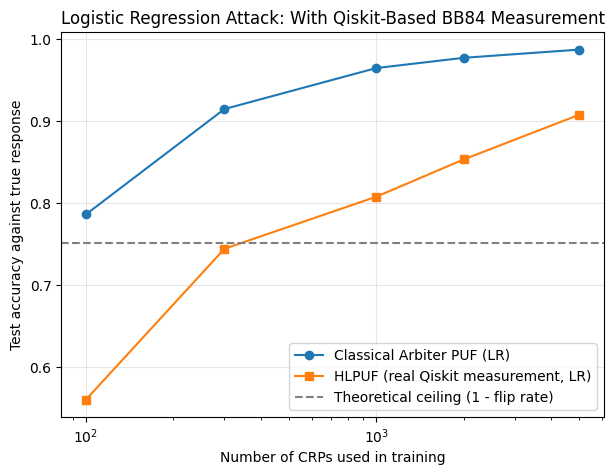

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(crp_sizes, acc_clean_list, 'o-', label='Classical Arbiter PUF (LR)')
plt.plot(crp_sizes, acc_noisy_list, 's-', label='HLPUF (real Qiskit measurement, LR)')
plt.axhline(1 - flip_rate, color='gray', linestyle='--', label='Theoretical ceiling (1 - flip rate)')
plt.xscale('log')
plt.xlabel('Number of CRPs used in training')
plt.ylabel('Test accuracy against true response')
plt.title('Logistic Regression Attack: With Qiskit-Based BB84 Measurement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()